# Análisis Comparativo de Conformaciones de Lípidos

## Clasificación e Interpretabilidad de características estructurales (**Mouse** vs **NMR**)

**Objetivo**: Identificar y cuantificar qué características estructurales diferencian lípidos en contextos **Mouse** vs **NMR**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### Cargar datos

In [2]:
%%time
# Estructura de datos
data: dict[str, dict[str, np.ndarray]] = {}

target_folders = ["Mouse", "NMR"]

# Extraer archivos .npy
for folder_name in target_folders:
    sub_folder = Path(folder_name)

    if sub_folder.is_dir():
        data[sub_folder.name] = {
            file.stem: np.load(file) for file in sub_folder.glob("*.npy")
        }

# Obtener información sobre valores nulos, valores infinitos, tipo de dato y forma
for d in data:
    for lipid in data[d]:
        array = data[d][lipid]
        nans = np.isnan(array).sum()
        infs = np.isinf(array).sum()
        dtype = array.dtype
        shape = array.shape
        print(
            f"Array {d} {lipid}: nans={nans}, infs={infs}, dtype={dtype}, shape={shape}"
        )

Array Mouse g3_DPSM_heads_resids: nans=0, infs=0, dtype=int64, shape=(342,)
Array Mouse g3_DPSM_tails: nans=0, infs=0, dtype=float64, shape=(342, 401, 201)
Array Mouse artificial_volume: nans=0, infs=0, dtype=float64, shape=(1,)
Array Mouse g3_DPSM_heads: nans=0, infs=0, dtype=float64, shape=(342, 401, 201)
Array Mouse g3_CHOL_head: nans=0, infs=0, dtype=float64, shape=(170, 401, 201)
Array Mouse g3_CHOL_head_resids: nans=0, infs=0, dtype=int64, shape=(170,)
Array Mouse g3_DPSM_tails_resids: nans=0, infs=0, dtype=int64, shape=(342,)
Array Mouse g3_CHOL_body_resids: nans=0, infs=0, dtype=int64, shape=(170,)
Array Mouse g3_CHOL_body: nans=0, infs=0, dtype=float64, shape=(170, 401, 201)
Array NMR g3_DPSM_heads_resids: nans=0, infs=0, dtype=int64, shape=(170,)
Array NMR g3_DPSM_tails: nans=0, infs=0, dtype=float64, shape=(170, 401, 201)
Array NMR artificial_volume: nans=0, infs=0, dtype=float64, shape=(1,)
Array NMR g3_DPSM_heads: nans=0, infs=0, dtype=float64, shape=(170, 401, 201)
Array 

No existen valores nulos. Sin embargo, todos los arrays que son `resids` son en realidad índices. Además, `artificial_volume` solamente es un único valor.

In [3]:
# Ejemplo resids
data["Mouse"]["g3_CHOL_body_resids"][:10]

array([ 2,  5,  6,  7,  8, 14, 16, 17, 22, 24])

In [4]:
# Artificial volume
data["Mouse"]["artificial_volume"], data["NMR"]["artificial_volume"]

(array([1052298.72674169]), array([886284.35260828]))

---

### Análisis de datos exploratorio
Se obtendrán estadísticas descriptivas de los datos 3D de lípidos (No `artificial_volume` o `resids`).

In [5]:
# DataFrame stats
rows = []
for d in data:
    for lipid in data[d]:
        if lipid != "artificial_volume" and not lipid.endswith("resids"):
            array = data[d][lipid]
            rows.append(
                {
                    "Group": d,
                    "Lipid": lipid,
                    "Size": array.size,
                    "Mean": np.mean(array),
                    "Median": np.median(array),
                    "Std": np.std(array),
                    "Min": np.min(array),
                    "Max": np.max(array),
                    "Q25": np.percentile(array, 25),
                    "Q75": np.percentile(array, 75),
                }
            )

df = pd.DataFrame(rows)

---

#### Gráficas de lípidos

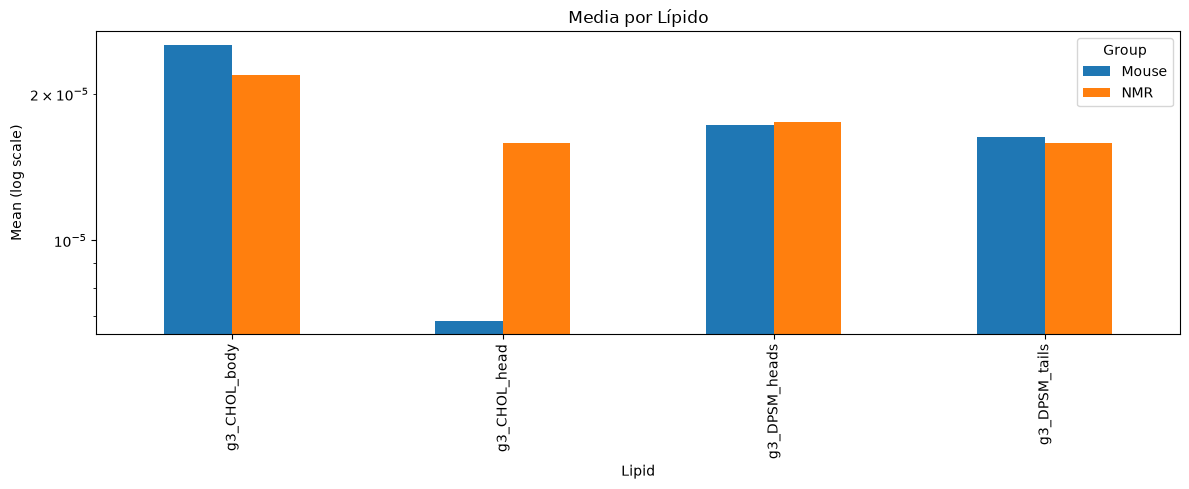

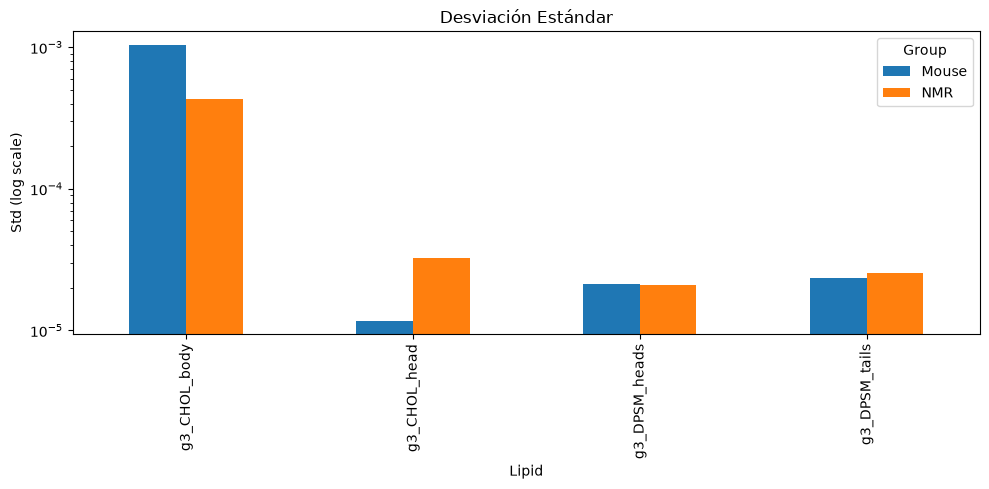

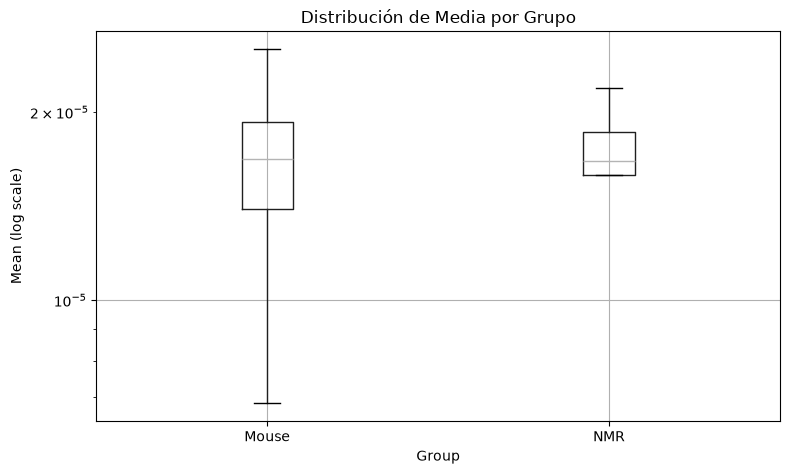

In [6]:
# Gráficas Datos 3D
# Gráfica 1: Media por lípido
df.pivot_table(values="Mean", index="Lipid", columns="Group").plot(
    kind="bar", figsize=(12, 5)
)
plt.title("Media por Lípido")
plt.ylabel("Mean (log scale)")
plt.yscale("log")
plt.tight_layout()
plt.savefig("figures/mean.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfica 2: Desviación estándar
df.pivot_table(values="Std", index="Lipid", columns="Group").plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Desviación Estándar")
plt.ylabel("Std (log scale)")
plt.yscale("log")
plt.tight_layout()
plt.savefig("figures/std.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfica 3: Distribución media por grupo
df.boxplot(column="Mean", by="Group", figsize=(8, 5))
plt.title("Distribución de Media por Grupo")
plt.ylabel("Mean (log scale)")
plt.yscale("log")
plt.suptitle("")
plt.tight_layout()
plt.savefig("figures/boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

Los lípidos `g3_DPSM_heads` y `g3_DPSM_tails` presentan una media muy parecida en ambos grupos. En `g3_CHOL_body`, **Mouse** presenta media ligeramente mayor. Sin embargo, hay una diferencia evidente en `g3_CHOL_head` donde el grupo **NMR** tiene una media mucho más alta. Esta diferencia indica una concentración similar de lípidos en ambos grupos excepto en `g3_CHOL_head` donde la concentración para **Mouse** es sumamente menor al grupo **NMR**.

En la comparación de la desviación estándar igualmente en `g3_DPSM_heads` y `g3_DPSM_tails` podemos encontrar que ambos grupos son similares. Las mayores diferencias se encuentran entre los lípidos de colesterol: en `g3_CHOL_body`, **Mouse** presenta valores más altos mientras que en `g3_CHOL_head`, **NMR** es más alto. En `g3_CHOL_body` hay datos más variables (mayor desviación estándar).

La distribución de media por grupo muestra que el rango es más amplio para el grupo **Mouse**, indicando que los datos están más dispersos que **NMR**. No obstante, los datos son más simétricos en **Mouse**.

---

#### Gráficas de lípidos (residuos)

In [7]:
# DataFrame stats resids
rows = []
for d in data:
    for lipid in data[d]:
        if lipid != "artificial_volume" and lipid.endswith("resids"):
            array = data[d][lipid]
            rows.append(
                {
                    "Group": d,
                    "Lipid": lipid,
                    "Size": array.size,
                    "Mean": np.mean(array),
                    "Median": np.median(array),
                    "Std": np.std(array),
                    "Min": np.min(array),
                    "Max": np.max(array),
                    "Q25": np.percentile(array, 25),
                    "Q75": np.percentile(array, 75),
                }
            )

df_resids = pd.DataFrame(rows)

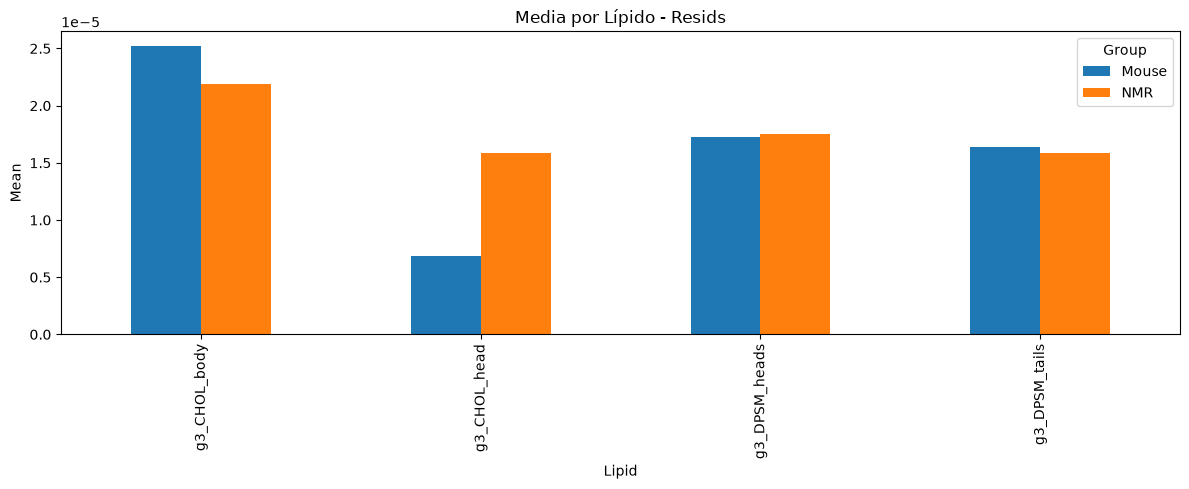

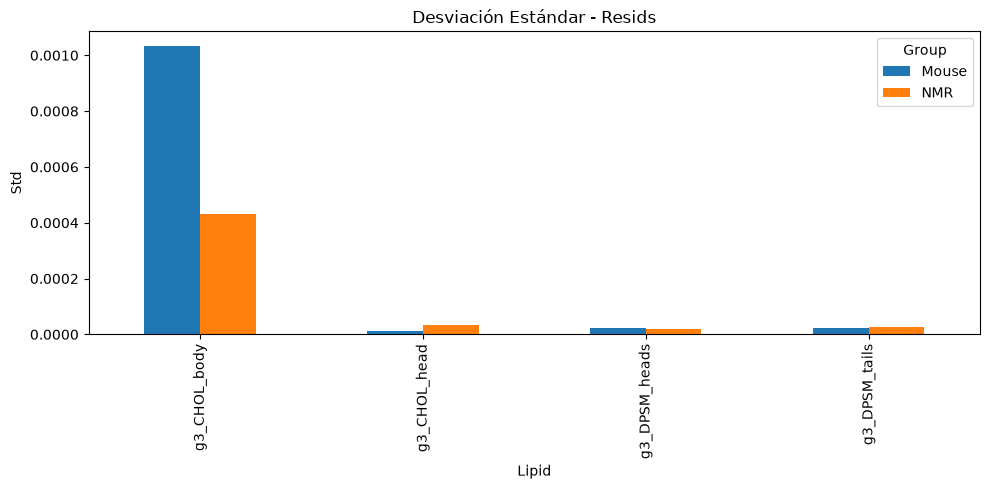

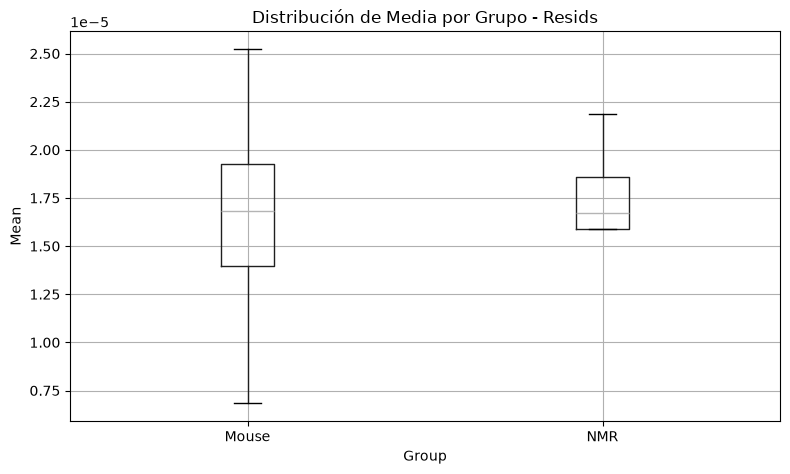

In [8]:
# Gráficas resids
# Gráfica 1: Media por lípido - Resids
df.pivot_table(values="Mean", index="Lipid", columns="Group").plot(
    kind="bar", figsize=(12, 5)
)
plt.title("Media por Lípido - Resids")
plt.ylabel("Mean")
plt.tight_layout()
plt.savefig("figures/mean_resids.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfica 2: Desviación estándar - Resids
df.pivot_table(values="Std", index="Lipid", columns="Group").plot(
    kind="bar", figsize=(10, 5)
)
plt.title("Desviación Estándar - Resids")
plt.ylabel("Std")
plt.tight_layout()
plt.savefig("figures/std_resids.png", dpi=150, bbox_inches="tight")
plt.show()

# Gráfica 3: Distribución media por grupo - Resids
df.boxplot(column="Mean", by="Group", figsize=(8, 5))
plt.title("Distribución de Media por Grupo - Resids")
plt.ylabel("Mean")
plt.suptitle("")
plt.tight_layout()
plt.savefig("figures/boxplot_resids.png", dpi=150, bbox_inches="tight")
plt.show()

Comparando los valores de la media por lípido para los residuos se puede ver que las gráficas son similares a la media de los datos 3D, solamente que en `g3_CHOL_head` para el grupo **Mouse** la media del residuo muestra un valor mayor que a la anterior gráfica.

Otra diferencia es en las desviaciones estándar para los residuos de lípidos. Las desviaciones estándar para `g3_CHOL_head`, `g3_DPSM_heads` y `g3_DPSM_tails` son cercanos a cero (<0.0002). De manera consistente con la gráfica anterior de desviaciones estándar, el grupo **Mouse** tiene una mayor variabilidad en los datos pero ahora la diferencia con el grupo **NMR** es ~2x.

Para la distribución media por grupo de los residuos la gráfica es similar a la distribución anterior, con la diferencia que los datos para el grupo **Mouse** son más simétricos (caja de dispersión).

---

#### Volumen de caja
Para el volumen de caja (`artificial_volume`), el grupo **Mouse** tiene **18.7%** más volumen que **NMR**. Las densidades están normalizadas por volumen de caja.

In [9]:
pd.DataFrame({
    "Mouse_AV": data["Mouse"]["artificial_volume"],
    "NMR_AV": data["NMR"]["artificial_volume"]
})

,Mouse_AV,NMR_AV
0,1.052299e+06,886284.352608


In [10]:
(data["Mouse"]["artificial_volume"] - data["NMR"]["artificial_volume"]) / data["NMR"]["artificial_volume"] * 100

array([18.73150233])

---

#### Estadísticas
En **Mouse**, `g3_CHOL_head` presenta la menor media entre los lípidos teniendo una distribución más dispersa. En `g3_CHOL_body` hay datos más variables (mayor desviación estándar).

In [11]:
# Mouse
df[df["Group"] == "Mouse"][["Lipid", "Mean", "Std"]].T

,0,1,2,3
Lipid,g3_DPSM_tails,g3_DPSM_heads,g3_CHOL_head,g3_CHOL_body
Mean,0.000016,0.000017,0.000007,0.000025
Std,0.000024,0.000021,0.000012,0.001034


Para **NMR**, las medias para cada lípido son muy similares. Se destaca únicamente, igual que en **Mouse**, `g3_CHOL_body` que tiene una desviación estándar más alta comparada con los otros lípidos.

In [12]:
# NMR
df[df["Group"] == "NMR"][["Lipid", "Mean", "Std"]].T

,4,5,6,7
Lipid,g3_DPSM_tails,g3_DPSM_heads,g3_CHOL_head,g3_CHOL_body
Mean,0.000016,0.000018,0.000016,0.000022
Std,0.000025,0.000021,0.000032,0.000432


In [13]:
print("RELACIÓN")
print(
    "Relación Mouse CHOL head / body:",
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_CHOL_head")]["Mean"].values[0] /
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_CHOL_body")]["Mean"].values[0]
)
print(
    "Relación Mouse DPSM heads / tails:",
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_DPSM_heads")]["Mean"].values[0] /
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_DPSM_tails")]["Mean"].values[0]
)
print(
    "Relación NMR CHOL head / body:",
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_CHOL_head")]["Mean"].values[0] /
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_CHOL_body")]["Mean"].values[0]
)
print(
    "Relación NMR DPSM heads / tails:",
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_DPSM_heads")]["Mean"].values[0] /
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_DPSM_tails")]["Mean"].values[0]
)

print("--------------")
print("DIFERENCIA")
print(
    "Diferencia Mouse CHOL head - body:",
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_CHOL_head")]["Mean"].values[0] -
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_CHOL_body")]["Mean"].values[0]
)
print(
    "Diferencia Mouse DPSM heads - tails:",
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_DPSM_heads")]["Mean"].values[0] -
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_DPSM_tails")]["Mean"].values[0]
)
print(
    "Diferencia NMR CHOL head - body:",
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_CHOL_head")]["Mean"].values[0] -
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_CHOL_body")]["Mean"].values[0]
)
print(
    "Diferencia NMR DPSM heads - tails:",
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_DPSM_heads")]["Mean"].values[0] -
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_DPSM_tails")]["Mean"].values[0]
)

print("--------------")
print("COEFICIENTE DE VARIACIÓN (Std/Mean)")
print(
    "Coef.Var Mouse CHOL head:",
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_CHOL_head")]["Std"].values[0] /
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_CHOL_head")]["Mean"].values[0]
)
print(
    "Coef.Var Mouse CHOL body:",
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_CHOL_body")]["Std"].values[0] /
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_CHOL_body")]["Mean"].values[0]
)
print(
    "Coef.Var Mouse DPSM heads:",
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_DPSM_heads")]["Std"].values[0] /
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_DPSM_heads")]["Mean"].values[0]
)
print(
    "Coef.Var Mouse DPSM tails:",
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_DPSM_tails")]["Std"].values[0] /
    df[(df["Group"] == "Mouse") & (df["Lipid"] == "g3_DPSM_tails")]["Mean"].values[0]
)
print(
    "Coef.Var NMR CHOL head:",
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_CHOL_head")]["Std"].values[0] /
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_CHOL_head")]["Mean"].values[0]
)
print(
    "Coef.Var NMR CHOL body:",
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_CHOL_body")]["Std"].values[0] /
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_CHOL_body")]["Mean"].values[0]
)
print(
    "Coef.Var NMR DPSM heads:",
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_DPSM_heads")]["Std"].values[0] /
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_DPSM_heads")]["Mean"].values[0]
)
print(
    "Coef.Var NMR DPSM tails:",
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_DPSM_tails")]["Std"].values[0] /
    df[(df["Group"] == "NMR") & (df["Lipid"] == "g3_DPSM_tails")]["Mean"].values[0]
)

RELACIÓN
Relación Mouse CHOL head / body: 0.27102591432047163
Relación Mouse DPSM heads / tails: 1.0557968361392474
Relación NMR CHOL head / body: 0.7256012612207168
Relación NMR DPSM heads / tails: 1.1037052107067948
--------------
DIFERENCIA
Diferencia Mouse CHOL head - body: -1.839509422226143e-05
Diferencia Mouse DPSM heads - tails: 9.125280571546951e-07
Diferencia NMR CHOL head - body: -5.999080833123369e-06
Diferencia NMR DPSM heads - tails: 1.6464028068698777e-06
--------------
COEFICIENTE DE VARIACIÓN (Std/Mean)
Coef.Var Mouse CHOL head: 1.715159835463001
Coef.Var Mouse CHOL body: 40.98304488226502
Coef.Var Mouse DPSM heads: 1.2401509271880595
Coef.Var Mouse DPSM tails: 1.44268417117492
Coef.Var NMR CHOL head: 2.048527361129254
Coef.Var NMR CHOL body: 19.742156834361108
Coef.Var NMR DPSM heads: 1.1872533301324992
Coef.Var NMR DPSM tails: 1.5925113045397306


**Relación**
* **Mouse**
    * **`CHOL` `head` / `body`**: La parte del denominador está más estructurada.
    * **`DPSM` `heads` / `tails`**: Tiene un lípido casi sin diferencia (uniforme).
* **NMR**
    * **`CHOL` `head` / `body`**: Parte del denominador más estructurada, pero más uniforme que en Mouse.
    * **`DPSM` `heads` / `tails`**: Tiene un lípido casi sin diferencia (uniforme).

**Diferencia**
* **Mouse**
    * **`CHOL` `head` - `body`**: Parte de `body` más densa.
    * **`DPSM` `heads` - `tails`**: Parte de `heads` más densa.
* **NMR**
    * **`CHOL` `head` - `body`**: Parte de `body` más densa; sin embargo, es mayor la diferencia en Mouse.
    * **`DPSM` `heads` - `tails`**: Parte de `heads` más densa; sin embargo, es mayor la diferencia en Mouse.

**Coeficiente de variación**
Ambos grupos presentan un coeficiente de variación extremo (CV > 100%).
* **`CHOL` `head`**: Existe alta variabilidad ~1.7-2.0x en ambos grupos.
* **`CHOL` `body`**: Variabilidad extrema para ambos grupos ~41-20x. Mouse tiene el doble de variabilidad que NMR.
* **`DPSM` `heads`**: Alta variabilidad ~1.2x en ambos grupos siendo la menor comparada con otros lípidos (~1.2x vs ~1.4-1.6x).
* **`DPSM` `tails`**: Alta variabilidad ~1.4-1.6x en ambos grupos.

---

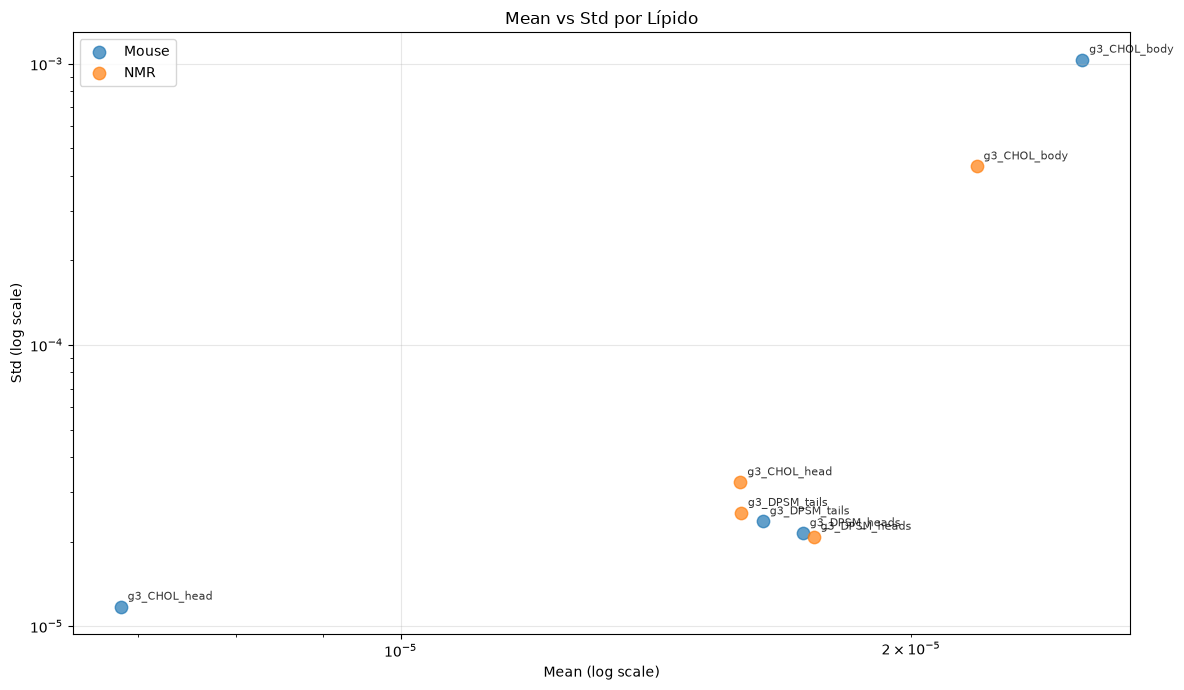

In [14]:
# Scatter plot: Mean vs Std, coloreando por grupo con etiquetas
plt.figure(figsize=(12, 7))
for group in df["Group"].unique():
    subset = df[df["Group"] == group]
    plt.scatter(subset["Mean"], subset["Std"], label=group, s=80, alpha=0.7)
    
    # Agregar etiquetas a cada punto
    for idx, row in subset.iterrows():
        plt.annotate(row["Lipid"], 
                    (row["Mean"], row["Std"]),
                    fontsize=8,
                    alpha=0.8,
                    xytext=(5, 5),
                    textcoords="offset points")

plt.xlabel("Mean (log scale)")
plt.ylabel("Std (log scale)")
plt.title("Mean vs Std por Lípido")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/scatter_mean_vs_std.png", dpi=150, bbox_inches="tight")
plt.show()

Se presenta un clúster de lípidos con valores Mean vs Std similares. Se destacan los lípidos de colesterol:
1. **`CHOL` `head`**: 
    * **Mouse**: Lípido con valores bajos (media y desviación estándar).
    * **NMR**: Media y desviación estándar más altos que Mouse.

2. **`CHOL` `body`**: El tipo de lípido tiene la mayor media y desviación estándar entre los demás, siendo esta característica más pronunciada en el grupo Mouse.

---

Se realizará una matriz de correlación. Sin embargo, solamente se realizará entre pares de los tipos de lípidos `CHOL` y `DPSM`:

In [15]:
# Verificar si hay misma forma

# Mouse
print(data["Mouse"]["g3_DPSM_heads"].shape == data["Mouse"]["g3_DPSM_tails"].shape)
print(data["Mouse"]["g3_CHOL_head"].shape == data["Mouse"]["g3_CHOL_body"].shape)

# NMR
print(data["NMR"]["g3_DPSM_heads"].shape == data["NMR"]["g3_DPSM_tails"].shape)
print(data["NMR"]["g3_CHOL_head"].shape == data["NMR"]["g3_CHOL_body"].shape)

True
True
True
True


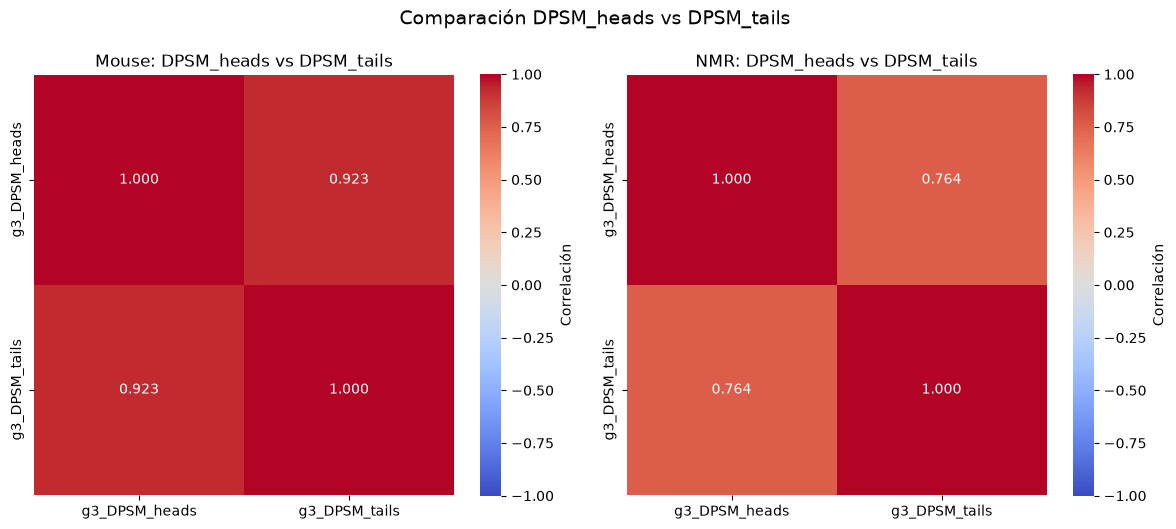

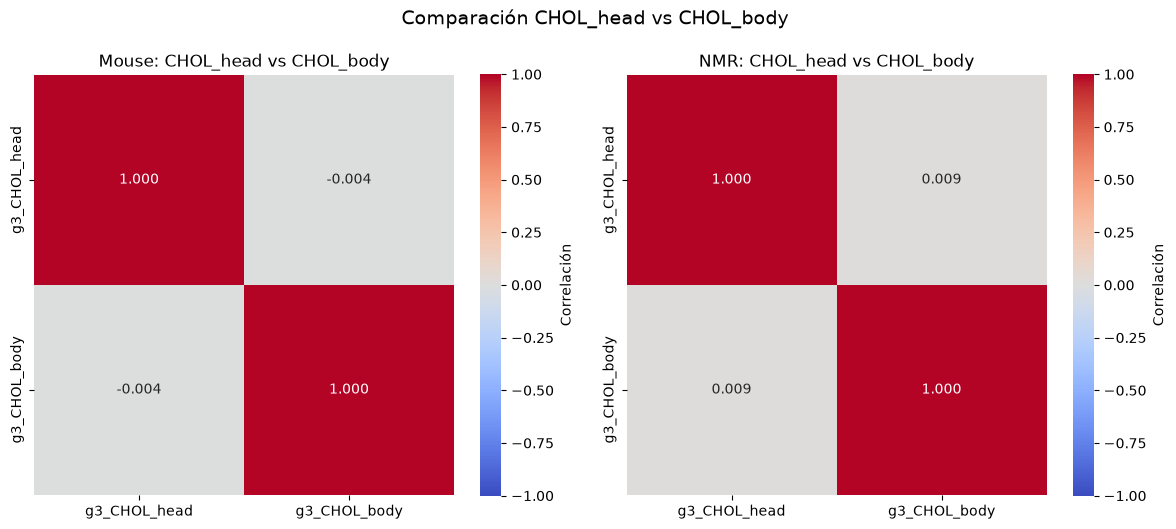

In [16]:
# Heatmap comparativo: Mouse vs NMR lado a lado
pairs = [
    ("g3_DPSM_heads", "g3_DPSM_tails"),
    ("g3_CHOL_head", "g3_CHOL_body")
]

for lipid1, lipid2 in pairs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    for idx, group in enumerate(["Mouse", "NMR"]):
        # Verificar que tengan el mismo shape
        if data[group][lipid1].shape == data[group][lipid2].shape:
            # Aplanar y crear DataFrame
            df_pair = pd.DataFrame({
                lipid1: data[group][lipid1].flatten(),
                lipid2: data[group][lipid2].flatten()
            })
            
            # Calcular correlación
            corr = df_pair.corr()
            
            # Visualizar en subplot
            sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", 
                        center=0, vmin=-1, vmax=1, 
                        cbar_kws={"label": "Correlación"},
                        square=True, ax=axes[idx])
            axes[idx].set_title(f"{group}: {lipid1.replace('g3_', '')} vs {lipid2.replace('g3_', '')}")
    
    plt.suptitle(f"Comparación {lipid1.replace('g3_', '')} vs {lipid2.replace('g3_', '')}", 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f"figures/heatmap_comparison_{lipid1}_{lipid2}.png", dpi=150, bbox_inches="tight")
    plt.show()

* **`DPSM` `heads` vs `DPSM` `tails`**: La correlación entre estos dos lípidos es alta en ambos grupos (**Mouse**: **0.923**, **NMR**: **0.764**).  Cuando la cabeza varía, la cola varía proporcionalmente.

* **`CHOL` `head` vs `CHOL` `body`**: La correlación es casi igual a cero (**Mouse**: **-0.004**, **NMR**: **0.009**). La cabeza y el cuerpo varían independientemente.

---

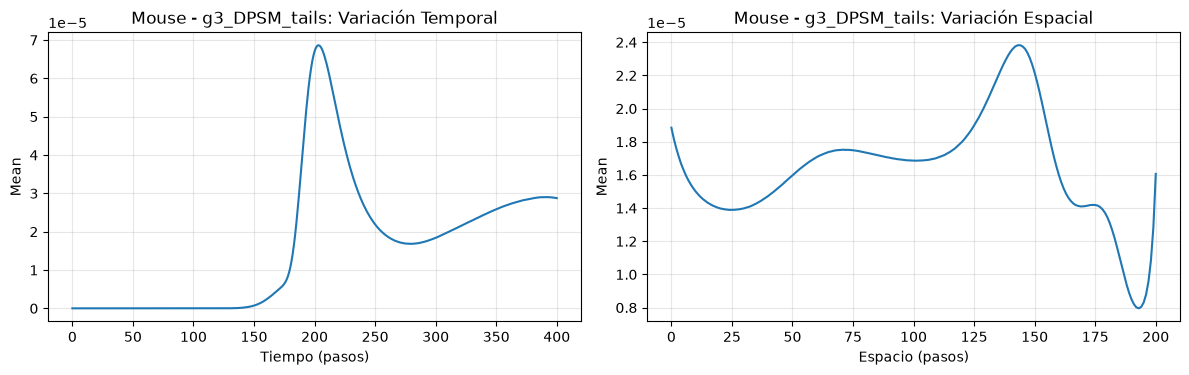

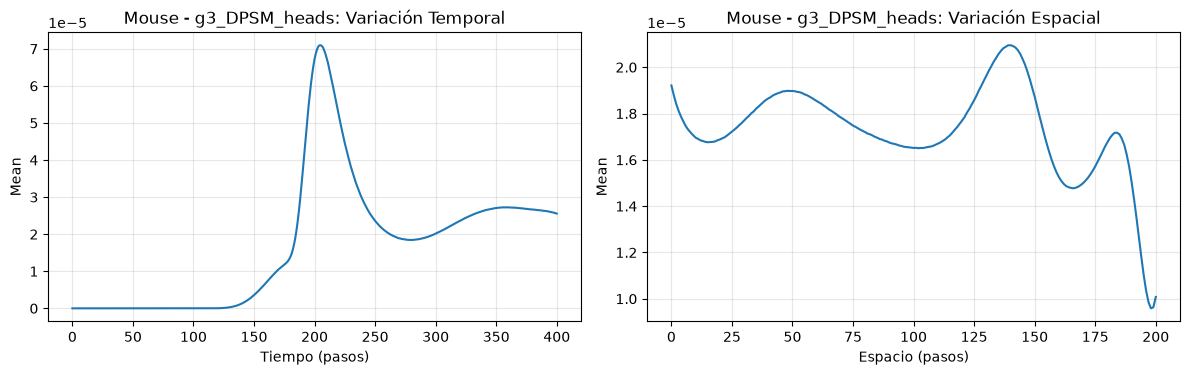

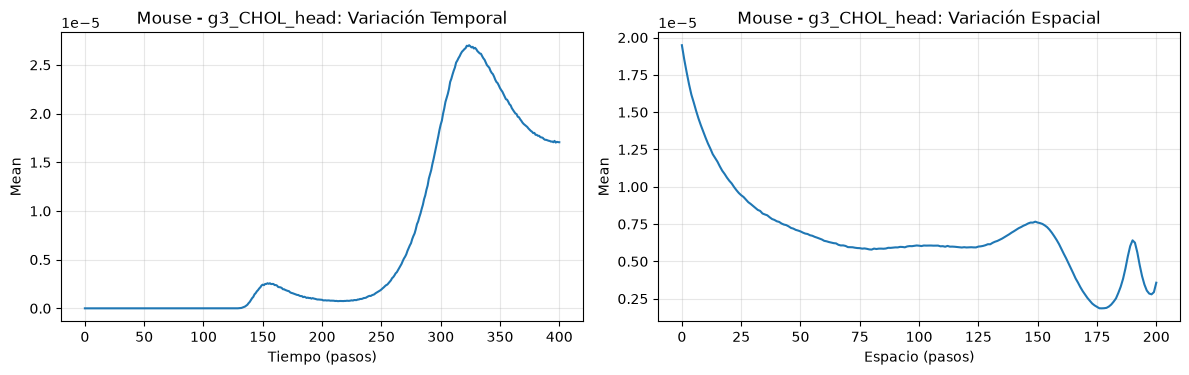

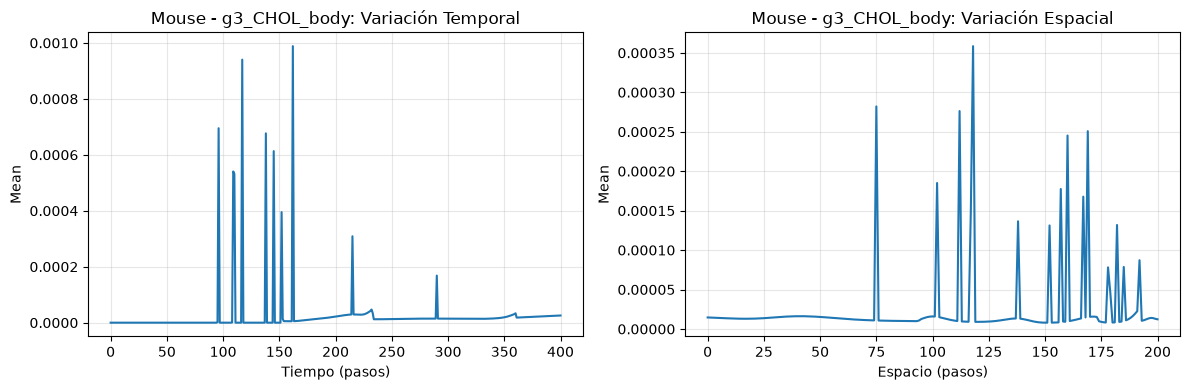

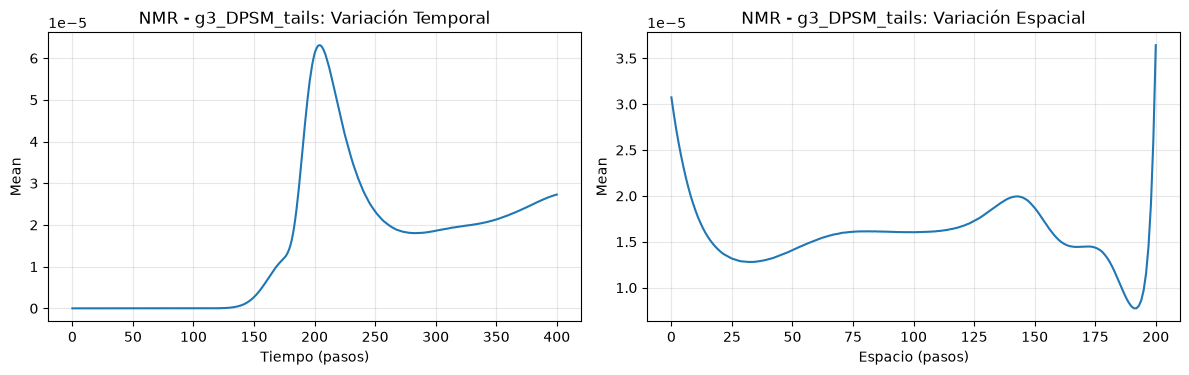

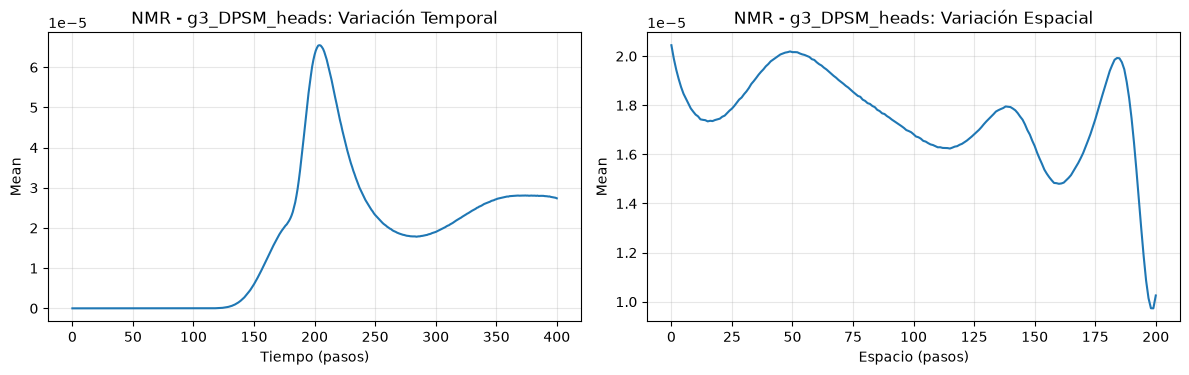

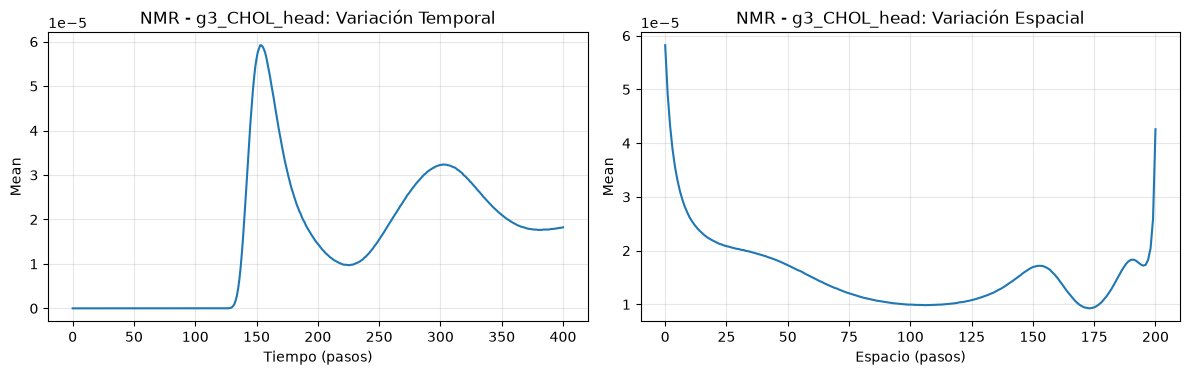

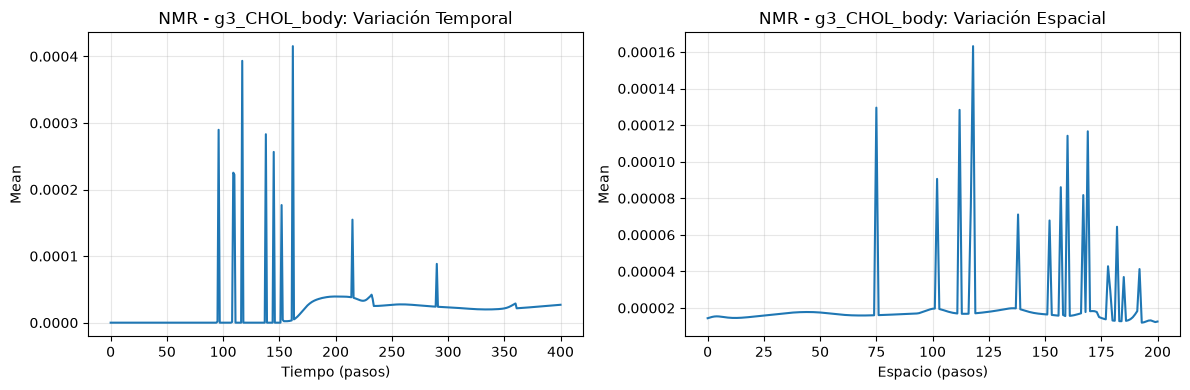

In [17]:
# Explorar variación en dimensiones 3D: temporal vs espacial

for group in ["Mouse", "NMR"]:
    for lipid in data[group]:
        if lipid != "artificial_volume" and not lipid.endswith("resids"):
            array = data[group][lipid]
            
            # Variación temporal: media en cada paso de tiempo
            temporal = np.mean(array, axis=(0, 2))  # Promediar residuos y espacio
            
            # Variación espacial: media en cada paso espacial
            spatial = np.mean(array, axis=(0, 1))   # Promediar residuos y tiempo
            
            # Graficar temporal
            plt.figure(figsize=(12, 4))
            
            plt.subplot(1, 2, 1)
            plt.plot(temporal)
            plt.title(f"{group} - {lipid}: Variación Temporal")
            plt.xlabel("Tiempo (pasos)")
            plt.ylabel("Mean")
            plt.grid(True, alpha=0.3)
            
            # Graficar espacial
            plt.subplot(1, 2, 2)
            plt.plot(spatial)
            plt.title(f"{group} - {lipid}: Variación Espacial")
            plt.xlabel("Espacio (pasos)")
            plt.ylabel("Mean")
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(f"figures/3d_exploration_{group}_{lipid}.png", dpi=150, bbox_inches="tight")
            plt.show()

* **Mouse**
    * Variación temporal: Se presentan en los lípidos `DPSM` una variación similar para `heads` y `tails`. Esta cambia para lípidos de colesterol, donde especialmente la variación en `body` es irregular.
    * Variación espacial: Igualmente los lípidos `DPSM` `heads` y `tails` tienen una variación parecida. En lípidos de colesterol para `head` disminuye de ~2.0 a ~0.625 y posteriormente se mantiene constante durante el espacio y al final oscila. En `body` podemos ver una similitud a su variación temporal, con la diferencia que se vuelve más irregular al incremento de espacio.

* **NMR**
    * Variación temporal: Los lípidos de tipo `DPSM` tienen una variación similar. También la variación del lípido de colesterol `head` tiene una variación parecida, con una cresta adicional. La variación del lípido de colesterol `body` tiene una variación irregular.
    * Variación espacial: Las variaciones espaciales para cada tipo de lípido difieren notablemente en este grupo. En `DPSM heads`, `DPSM tails` y `CHOL head` la media disminuye en el rango espacial x≈0-25, desde ~0.3 hasta ~6. En `DPSM heads` se observan 3 picos locales distribuidos en el eje espacial, indicando oscilaciones alrededor de la tendencia. La variación espacial de `CHOL body` presenta fluctuaciones abruptas, especialmente en x>75.

En ambos grupos, los lípidos de tipo `DPSM` presentan variación temporal muy similar. Para colesterol solamente en `CHOL body` podemos ver que sí hay una similitud por la irregularidad entre el tiempo ~100-150. En cambio, para la variación espacial hay bastante diferencia en ambos grupos. También en `CHOL body` se puede ver mayor irregularidad para x>75.

---

### Feature engineering

Para la preparación del conjunto de datos que se utilizará para la clasificación se decidió que se prepararán dos para cada tipo de lípido (`CHOL` y `DPSM`).
Con estos dos conjuntos se entrenarán dos modelos para analizar si cada uno puede diferenciar entre los grupos **Mouse** y **NMR** para los dos tipos de lípido `CHOL` y `DPSM`.

Para cada molécula que se encuentra en `data` se obtendrán las siguientes características:
* Residual: Para la $i$-ésima molécula obtener su residual.
* Magnitud: Obtener media y desviación estándar.
* Proporciones: Obtener el cociente entre las medias de `head` y `body` o `heads` y `tails` dependiendo del tipo de lípido. Igualmente para las desviaciones estándar.
* Correlación: El coeficiente $r$ de Pearson entre `head` y `body` o `heads` y `tails` dependiendo del tipo de lípido.
* Amplitud: Valores de rango, mínimo y máximo valor.

In [67]:
%%time
chol_feats, dpsm_feats = [], []

for group in ("Mouse", "NMR"):
    for lipid_type in ("CHOL", "DPSM"):

        if lipid_type == "CHOL":
            head_data = data[group]["g3_CHOL_head"]
            body_data = data[group]["g3_CHOL_body"]
            head_resids = data[group]["g3_CHOL_head_resids"]
            body_resids = data[group]["g3_CHOL_body_resids"]

            n_molecules = head_data.shape[0]
            for i in range(n_molecules):

                mean_head = np.mean(head_data[i, :, :])
                mean_body = np.mean(body_data[i, :, :])
                std_head = np.std(head_data[i, :, :])
                std_body = np.std(body_data[i, :, :])
                min_head = np.min(head_data[i, :, :])
                max_head = np.max(head_data[i, :, :])
                min_body = np.min(body_data[i, :, :])
                max_body = np.max(body_data[i, :, :])

                dict_feats = {
                    "resid": head_resids[i],
                    "lipid_type": lipid_type,
                    "mean_head": mean_head,
                    "mean_body": mean_body, 
                    "std_head": std_head,
                    "std_body": std_body,
                    "ratio_head_body": mean_head / mean_body,
                    "ratio_std_head_body": std_head / std_body,
                    "corr_head_body": np.corrcoef(head_data[i, :, :].flatten(), body_data[i, :, :].flatten())[0, 1],
                    "min_head": min_head,
                    "max_head": max_head,
                    "range_head": max_head - min_head,
                    "min_body": min_body,
                    "max_body": max_body,
                    "range_body": max_body - min_body,
                    "target": 0 if group == "Mouse" else 1
                }

                chol_feats.append(dict_feats)
        else:  # DPSM
            heads_data = data[group]["g3_DPSM_heads"]
            tails_data = data[group]["g3_DPSM_tails"]
            heads_resids = data[group]["g3_DPSM_heads_resids"]
            tails_resids = data[group]["g3_DPSM_tails_resids"]

            n_molecules = heads_data.shape[0]
            for i in range(n_molecules):

                mean_heads = np.mean(heads_data[i, :, :])
                mean_tails = np.mean(tails_data[i, :, :])
                std_heads = np.std(heads_data[i, :, :])
                std_tails = np.std(tails_data[i, :, :])
                min_heads = np.min(heads_data[i, :, :])
                max_heads = np.max(heads_data[i, :, :])
                min_tails = np.min(tails_data[i, :, :])
                max_tails = np.max(tails_data[i, :, :])

                dict_feats = {
                    "resid": heads_resids[i],
                    "lipid_type": lipid_type,
                    "mean_heads": mean_heads,
                    "mean_tails": mean_tails,
                    "std_heads": std_heads,
                    "std_tails": std_tails,
                    "ratio_heads_tails": mean_heads / mean_tails,
                    "ratio_std_heads_tails": std_heads / std_tails,
                    "corr_heads_tails": np.corrcoef(heads_data[i, :, :].flatten(), tails_data[i, :, :].flatten())[0, 1],
                    "min_heads": min_heads,
                    "max_heads": max_heads,
                    "range_heads": max_heads - min_heads,
                    "min_tails": min_tails,
                    "max_tails": max_tails,
                    "range_tails": max_tails - min_tails,
                    "target": 0 if group == "Mouse" else 1
                }

                dpsm_feats.append(dict_feats)

CPU times: user 1min 9s, sys: 5 s, total: 1min 14s
Wall time: 9.35 s


In [68]:
df_chol = pd.DataFrame(chol_feats)
df_dpsm = pd.DataFrame(dpsm_feats)

In [69]:
df_chol.columns

Index(['resid', 'lipid_type', 'mean_head', 'mean_body', 'std_head', 'std_body',
       'ratio_head_body', 'ratio_std_head_body', 'corr_head_body', 'min_head',
       'max_head', 'range_head', 'min_body', 'max_body', 'range_body',
       'target'],
      dtype='str')

In [70]:
df_dpsm.columns

Index(['resid', 'lipid_type', 'mean_heads', 'mean_tails', 'std_heads',
       'std_tails', 'ratio_heads_tails', 'ratio_std_heads_tails',
       'corr_heads_tails', 'min_heads', 'max_heads', 'range_heads',
       'min_tails', 'max_tails', 'range_tails', 'target'],
      dtype='str')